In [1]:
#Importing the standard libraries
import numpy as np
np.set_printoptions(legacy='1.25',suppress=True)

import matplotlib.pyplot as plt
%matplotlib qt

#Importing the solver modules
from BaF_solver.system import System
from BaF_solver.obe_with_gradient import obe 
from BaF_solver.states import SigmaLevel,PiLevelParity
from BaF_solver.obe_with_gradient import Excitation, Static_Excitation
import time
import warnings
warnings.filterwarnings('ignore')
import datetime

/Users/mangesh/Documents/Git/BaF-solver/BaF_solver/obe_with_gradient.py:25: UserWarning: Could not detect diffeqpy. Only Python package for OBE solver available.
  warnings.warn(f"Could not detect diffeqpy. Only Python package for OBE solver available.")


In [2]:
#Reference ordering

Bz = 20.0
Ez = 0.0
b=System([0,2],['1/2-','3/2-','5/2-'],B_field = [0.0,0.0,Bz],E_stat_field=[0.0,0.0,Ez],ignore_mF = False)

start = time.perf_counter()

b.sigma_Hamiltonian.generate_bare()
b.sigma_Hamiltonian.Zeeman.generate_Zeeman()
b.sigma_Hamiltonian.Stark.generate_Stark()
b.pi_Hamiltonian.generate_bare()
b.pi_Hamiltonian.Zeeman.generate_Zeeman()
b.pi_Hamiltonian.Stark.generate_Stark()

#Next diagonalize the Hamiltonian for this system
b.sigma_Hamiltonian.diagonalize()
b.pi_Hamiltonian.diagonalize()


G_global = b.sigma_Hamiltonian.diagonalized_states
GH_global = np.round(b.sigma_Hamiltonian.diagonalized_Hamiltonian,3)
E_global =b.pi_Hamiltonian.diagonalized_states
EH_global = np.round(b.pi_Hamiltonian.diagonalized_Hamiltonian,3)

print(f"Bz = {Bz}.")
print(f"Static Hamiltonian took : {time.perf_counter()-start}s. ")

G = G_global#[0:96]
GH = GH_global#[0:96,0:96]
E = E_global[0:16]
EH = EH_global[0:16,0:16]

vec_prev_sigma = b.sigma_Hamiltonian.diagonalized_states_as_vectors
vec_prev_pi = b.pi_Hamiltonian.diagonalized_states_as_vectors

G0_mean = np.mean(np.diag(GH)[0:16])
G2_mean = np.mean(np.diag(GH)[16:80+16])
E_mean =  np.mean(np.diag(EH))

Bz = 20.0.
Static Hamiltonian took : 1.1362628749920987s. 


np.set_printoptions(legacy='1.25')
#Check the order of mF levels
max_sigma_state_array_ref = []
for i,sigma_states in enumerate(b.sigma_states):
    # I need to find, whcih of the diagonalized eigen states have the the maximum amplitude for the gien sigma state
    
    vec_prev = b.sigma_Hamiltonian.diagonalized_states_as_vectors #is a matricx wherre coliumns are eigne vectors
    #Check the ith entry of every vectors to see which one is the maximum
    test_vec = vec[:,i] 
    #find the index of the max
    max_idx = np.argmax(np.abs(test_vec))
    max_sigma_state_array_ref.append(max_idx)

print(max_sigma_state_array_ref)

max_pi_state_array_ref = []
for st in E:
    list_st = st.states
    list_amp = st.amplitude
    max_state_idx = np.argmax([np.abs(val) for val in list_amp])
    max_state = list_st[max_state_idx]
    max_pi_state_array_ref.append(max_state)
print(Bz, max_pi_state_array_ref)

In [3]:
GH_list = [] 
EH_list = [] 
H0_list = []
BR_list = []
Hint_1_list,Hint_2_list,Hint_3_list = [],[],[]
Hstatic_int_list = []
from scipy.linalg import block_diag

Bz_list = np.arange(20,30,1)#np.arange(1,31,0.25)
for Bz in Bz_list:
    b=System([0,2],['1/2-','3/2-','5/2-'],B_field = [0.0,0.0,Bz],E_stat_field=[0.0,0.0,Ez],ignore_mF = False)

    start = time.perf_counter()

    b.sigma_Hamiltonian.generate_bare()
    b.sigma_Hamiltonian.Zeeman.generate_Zeeman()
    b.sigma_Hamiltonian.Stark.generate_Stark()
    b.pi_Hamiltonian.generate_bare()
    b.pi_Hamiltonian.Zeeman.generate_Zeeman()
    b.pi_Hamiltonian.Stark.generate_Stark()

    #Next diagonalize the Hamiltonian for this system
    b.sigma_Hamiltonian.diagonalize()
    b.pi_Hamiltonian.diagonalize()


    G_global = b.sigma_Hamiltonian.diagonalized_states
    GH_global = b.sigma_Hamiltonian.diagonalized_Hamiltonian #np.round(b.sigma_Hamiltonian.diagonalized_Hamiltonian,3)
    E_global = b.pi_Hamiltonian.diagonalized_states
    EH_global = b.pi_Hamiltonian.diagonalized_Hamiltonian#np.round(b.pi_Hamiltonian.diagonalized_Hamiltonian,3)

    print(f"Bz = {Bz}.")
    print(f"Static Hamiltonian took : {time.perf_counter()-start}s. ")

    G_temp = G_global
    GH_temp = GH_global
    E_temp = E_global[0:16]
    EH_temp = EH_global[0:16,0:16]
    NG = len(G_temp)
    NE = len(E_temp)

    vec_current_sigma = b.sigma_Hamiltonian.diagonalized_states_as_vectors
    vec_current_pi = b.pi_Hamiltonian.diagonalized_states_as_vectors

    #check the new ground state's overlap with the the previous ground states    permutation_sigma = []
    vec_current_hermit = vec_current_sigma.conj().T
    permutation_sigma = []
    for i in range(len(G_temp)):
        #check current ith state ground state
        temp = vec_current_hermit@vec_prev_sigma[:,i]
        max_idx = np.argmax(np.abs(temp))
        permutation_sigma.append(max_idx)

    #check the new excited state's overlap with the the previous excited states
    permutation_pi = []
    vec_current_hermit = vec_current_pi.conj().T
    for j in range(len(E_temp)):
        #check current jth state excited state
        temp = vec_current_hermit@vec_prev_pi[:,j]
        max_idx = np.argmax(np.abs(temp))
        permutation_pi.append(max_idx)


    G_new = [G_temp[i] for i in permutation_sigma]
    E_new = [E_temp[j] for j in permutation_pi]
    GH_new_diag = np.diag(GH_temp)[permutation_sigma]
    EH_new_diag = np.diag(EH_temp)[permutation_pi]
    GH_list.append(GH_new_diag)
    EH_list.append(EH_new_diag)

    H0 = np.diag(np.append(GH_new_diag,EH_new_diag))
    assert np.allclose(np.imag(H0),np.zeros(H0.shape))
    H0_list.append(H0.astype(np.float64))

    b.generate_branching_ratios(G_new,E_new)
    BR = 0.96*b.branching_ratios
    assert np.allclose(np.imag(BR), np.zeros(BR.shape))

    BR_list.append(BR.astype(np.float64))

    start  = time.perf_counter()
    b.generate_interaction_Hamiltonian(G_new,E_new)
    Hint_1=b.interaction_Hamiltonian

    b.generate_interaction_Hamiltonian(G_new,E_new,pol=+1)
    Hint_2 = b.interaction_Hamiltonian

    b.generate_interaction_Hamiltonian(G_new,E_new,pol=-1)
    Hint_3 = b.interaction_Hamiltonian
    print(f'All Hamiltonians took : {time.perf_counter() - start} s.')

    Hint_1_list.append(Hint_1)
    Hint_2_list.append(Hint_2)
    Hint_3_list.append(Hint_3)

    #Read the operator to express the static electric field in the diagonalized basis
    U_sim_sigma = b.sigma_Hamiltonian.diagonalizing_Matrix
    Hstatic_int_sigma_temp = b.sigma_Hamiltonian.Stark.Z
    Hstatic_int_sigma_temp = U_sim_sigma.conj().T@Hstatic_int_sigma_temp@U_sim_sigma

    #Reorder with permutations
    H_temp_row = np.zeros_like(Hstatic_int_sigma_temp)
    H_temp_col = np.zeros_like(Hstatic_int_sigma_temp)
    for i in range(NG):
        H_temp_row[i,:] = Hstatic_int_sigma_temp[permutation_sigma[i],:]
    
    for i in range(NG):
        H_temp_col[:,i] = H_temp_row[:,permutation_sigma[i]]
    Hstatic_int_sigma = H_temp_col
    #Hstatic_int_sigma = Hstatic_int_sigma[3:4+1, 3:4+1]
    
    
    U_sim_pi = b.pi_Hamiltonian.diagonalizing_Matrix
    Hstatic_int_pi_temp = b.pi_Hamiltonian.Stark.Z
    Hstatic_int_pi_temp = U_sim_pi.conj().T@Hstatic_int_pi_temp@U_sim_pi
    #Reorder with permutations
    H_temp_row = np.zeros_like(Hstatic_int_pi_temp)
    H_temp_col = np.zeros_like(Hstatic_int_pi_temp)
    for i in range(NE):
        H_temp_row[i,:] = Hstatic_int_pi_temp[permutation_pi[i],:]
    
    for i in range(NE):
        H_temp_col[:,i] = H_temp_row[:,permutation_pi[i]]
    Hstatic_int_pi = H_temp_col[0:16,0:16]
    print(np.shape(Hstatic_int_pi))
    
    Hstatic_int = block_diag(Hstatic_int_sigma, Hstatic_int_pi)
    Hstatic_int_list.append(Hstatic_int)

    #rearragne the roder of the the vectors recorded as matrices too
    vec_prev_sigma,vec_prev_pi = vec_current_sigma[:,permutation_sigma],vec_current_pi[:,permutation_pi]
    

Bz = 20.
Static Hamiltonian took : 0.04183229198679328s. 
All Hamiltonians took : 1.6786927499924786 s.
(16, 16)
Bz = 21.
Static Hamiltonian took : 0.04047775000799447s. 
All Hamiltonians took : 1.7474689169903286 s.
(16, 16)
Bz = 22.
Static Hamiltonian took : 0.03958395801601s. 
All Hamiltonians took : 2.008653667027829 s.
(16, 16)
Bz = 23.
Static Hamiltonian took : 0.04012733299168758s. 
All Hamiltonians took : 1.9533378329942934 s.
(16, 16)
Bz = 24.
Static Hamiltonian took : 0.04313254100270569s. 
All Hamiltonians took : 1.7951356249977835 s.
(16, 16)
Bz = 25.
Static Hamiltonian took : 0.04433854197850451s. 
All Hamiltonians took : 1.676828416006174 s.
(16, 16)
Bz = 26.
Static Hamiltonian took : 0.03960587500478141s. 
All Hamiltonians took : 1.701756041002227 s.
(16, 16)
Bz = 27.
Static Hamiltonian took : 0.040073499985737726s. 
All Hamiltonians took : 1.7269929999893066 s.
(16, 16)
Bz = 28.
Static Hamiltonian took : 0.04026991699356586s. 
All Hamiltonians took : 1.663929249974899 s

In [4]:
import scipy
from scipy.interpolate import interp1d,CubicSpline

# Given data
B_vals = np.arange(20,30,1)  # shape (10,)
H0_vals = np.array(H0_list)  # shape (10, 112, 112)

BR_vals = np.array(BR_list)

Hint_1_vals = np.array(Hint_1_list)
Hint1_max = np.amax(np.abs(Hint_1_vals),axis=0)

Hint_2_vals = np.array(Hint_2_list)
Hint2_max = np.amax(np.abs(Hint_2_vals),axis=0)

Hint_3_vals = np.array(Hint_3_list)
Hint3_max = np.amax(np.abs(Hint_3_vals),axis=0)

Hstatic_int_vals = np.array(Hstatic_int_list)
print(np.shape(Hstatic_int_vals))
Hstatic_int_max = np.amax(np.abs(Hstatic_int_vals),axis=0)


interpol_kind = 'cubic'

def interpolate(x,y,real_imag = False):
    if real_imag == True:
        #y_interp_real = interp1d(x, np.real(y),     kind=interpol_kind, axis=0, bounds_error=False, fill_value='extrapolate')
        #y_interp_imag = interp1d(x, np.imag(y),     kind=interpol_kind, axis=0, bounds_error=False, fill_value='extrapolate')
        y_interp_real = CubicSpline(x, np.real(y))#,     kind=interpol_kind, axis=0, bounds_error=False, fill_value='extrapolate')
        y_interp_imag = CubicSpline(x, np.imag(y))#,     kind=interpol_kind, axis=0, bounds_error=False, fill_value='extrapolate')
        y_interp = (y_interp_real,y_interp_imag)
    else:
        y_interp = CubicSpline(x, y)#,     kind=interpol_kind, axis=0, bounds_error=False, fill_value='extrapolate')
        #y_interp = interp1d(x, y, kind=interpol_kind, axis=0, bounds_error=False, fill_value='extrapolate')
    return y_interp


"""numba based evaluation with scipy based creation"""
#@njit(complex128[:, :](int64,complex128[:],complex128[:, :]),cache = True)

"""
@njit(int64 (float64[:],float64),cache = True)
def find_interval(x, xi):
    n = len(x) - 1
    if xi <= x[0]:
        return 0
    if xi >= x[-1]:
        return n - 1
    low = 0
    high = n - 1
    while low <= high:
        mid = (low + high) // 2
        if x[mid] <= xi < x[mid + 1]:
            return mid
        elif xi < x[mid]:
            high = mid - 1
        else:
            low = mid + 1
    return n - 2

@njit(float64[:,:](float64[:],float64[:,:,:],float64[:]),cache = True)
def _evaluate_vector_spline(x, coefs, x_eval):
    
    #Evaluate vector-valued cubic spline.

    #x: shape (n,)
    #coefs: shape (n-1, N, 4), ordered as [c0, c1, c2, c3] for each dimension (SciPy order)
    3x_eval: shape (M,)

    #Returns: shape (M, N)
    
    n_minus1, N, _ = coefs.shape
    M = len(x_eval)
    out = np.empty((M, N), dtype=np.float64)

    for i in range(M):
        xi = x_eval[i]
        idx = find_interval(x, xi)
        dx = xi - x[idx]

        for j in range(N):
            # Correct Horner evaluation: ((((c0 * dx) + c1) * dx) + c2) * dx + c3
            c0 = coefs[idx, j, 0]  # dx^3
            c1 = coefs[idx, j, 1]  # dx^2
            c2 = coefs[idx, j, 2]  # dx^1
            c3 = coefs[idx, j, 3]  # dx^0
            out[i, j] = ((c0 * dx + c1) * dx + c2) * dx + c3
    return out

def make_fast_vector_spline(x: np.ndarray, coefs: np.ndarray):
    x = np.ascontiguousarray(x, dtype=np.float64)
    coefs = np.ascontiguousarray(coefs, dtype=np.float64)

    def spline(x_eval):
        x_eval = np.ascontiguousarray(x_eval, dtype=np.float64)
        return _evaluate_vector_spline(x, coefs, x_eval)

    return spline
"""

from BaF_solver.numba_cubicspline import make_fast_vector_spline
def numba_interpolate(x,y,real_imag = False):
    if real_imag == True:
        cs = CubicSpline(x, np.real(y))#,     kind=interpol_kind, axis=0, bounds_error=False, fill_value='extrapolate')
        coefs = np.transpose(cs.c, (1, 2, 0))
        y_interp_real = make_fast_vector_spline(x, coefs)

        cs = CubicSpline(x, np.imag(y))#,     kind=interpol_kind, axis=0, bounds_error=False, fill_value='extrapolate')
        coefs = np.transpose(cs.c, (1, 2, 0))
        y_interp_imag = make_fast_vector_spline(x, coefs)
        y_interp = (y_interp_real,y_interp_imag)
    else:
        cs = CubicSpline(x, y)
        coefs = np.transpose(cs.c, (1, 2, 0))
        y_interp = make_fast_vector_spline(x, coefs)#,     kind=interpol_kind, axis=0, bounds_error=False, fill_value='extrapolate')
    return y_interp



"""numba based function ends here"""





# Flatten for fast interpolation (shape: (10, 112*112))
H0_flat = H0_vals.reshape(len(B_vals), -1)
BR_flat = BR_vals.reshape(len(B_vals), -1)
Hint_1_flat = Hint_1_vals.reshape(len(B_vals), -1)
Hint_2_flat = Hint_2_vals.reshape(len(B_vals), -1)
Hint_3_flat = Hint_3_vals.reshape(len(B_vals), -1)
Hstatic_int_flat = Hstatic_int_vals.reshape(len(B_vals), -1)

"""
H0     = interpolate(B_vals, H0_flat)
BR     = interpolate(B_vals, BR_flat)
Hint_1 = interpolate(B_vals, Hint_1_flat,real_imag = True)
Hint_2 = interpolate(B_vals, Hint_2_flat,real_imag = True)
Hint_3 = interpolate(B_vals, Hint_3_flat,real_imag = True)

"""
H0     = numba_interpolate(B_vals, H0_flat)
BR     = numba_interpolate(B_vals, BR_flat)
Hint_1 = numba_interpolate(B_vals, Hint_1_flat,real_imag = True)
Hint_2 = numba_interpolate(B_vals, Hint_2_flat,real_imag = True)
Hint_3 = numba_interpolate(B_vals, Hint_3_flat,real_imag = True)

Hstatic_int = numba_interpolate(B_vals, Hstatic_int_flat)

"""
def get_interp_array(A_interp,shape,t,real_imag = False):
    if real_imag:
        real, imag = A_interp
        return (real(t).reshape(shape).astype(np.complex128),imag(t).reshape(shape).astype(np.complex128))
    else:
        return A_interp(t).reshape(shape).astype(np.complex128)
"""

(10, 112, 112)


'\ndef get_interp_array(A_interp,shape,t,real_imag = False):\n    if real_imag:\n        real, imag = A_interp\n        return (real(t).reshape(shape).astype(np.complex128),imag(t).reshape(shape).astype(np.complex128))\n    else:\n        return A_interp(t).reshape(shape).astype(np.complex128)\n'


z = [br[11,2] for br in BR_list]

B_range= np.arange(20,30,0.1)
y = np.empty_like(B_range)

for i,B in enumerate(B_range):
    br = get_interp_array(BR,(len(G),len(E)),B,real_imag = False)
    y[i] = br[11,2] 

plt.plot(B_vals,z,'or')    
plt.plot(B_range,y)

In [5]:
np.sqrt(12544)

112.0

def get_interp_array(A_interp,shape,t,real_imag = False):
    if real_imag:
        real, imag = A_interp
        return (real(t).reshape(shape).astype(np.complex128),imag(t).reshape(shape).astype(np.complex128))
    else:
        return A_interp(t).reshape(shape).astype(np.complex128)

n_total = len(G) + len(E)
H0_base = get_interp_array(H0,(n_total,n_total),20,real_imag = False)
H = get_interp_array(H0,(n_total,n_total),21.99,real_imag = False) - \
    H0_base
print(f"h max : {np.amax(H)}, H min : {np.amin(H)}")

temp = [item for item in enumerate(np.arange(1,31,0.25))]
print(temp)

for (i,B) in temp: 
    err = np.abs(H0_list[i] - get_interp_array(H0_interp,np.shape(H0_list[0]),B))
    print(f"B : {B}, error = {np.sum(err) :.3f}, max error : {np.amax(err) :.3f}")

import matplotlib.colors as colors
B = np.arange(20,30,0.1)
en = []
for i,Bval in enumerate(B):
    #en.append(H0_list[i])
    #plt.imshow(B,en,'.-');
    A = get_interp_array(Hint_2_interp,Hint_2.shape,Bval,real_imag = True)[0]
    norm = colors.LogNorm(vmin=1e-3, vmax=1)#np.abs(A.max() - A.min()))
    plt.clf()
    plt.imshow(A)#,norm=norm)
    plt.pause(0.1)

In [6]:
level_to_optimize = 14

In [7]:
#to select a desired set of transitions
Gamma = 2*np.pi*2.7
tsigma = 8.192/4
import random
def generate_transition(desired_transitions,polarization):
    
    field = []
    for item in desired_transitions:
        (i,j) = item
        rabi = random.uniform(0.1, 5.0)*Gamma
        pol = polarization
        groundState = G[i]
        excitedState = E[j]
        det = random.uniform(-1,1)*Gamma 
        pos = 0
        dia = 4*tsigma
        temp_field = Excitation(rabi,pol,groundState,excitedState,detuning = det,position = pos,diameter = dia ,shape = "Uniform")
        field.append(temp_field)
    
    return field,desired_transitions

In [8]:
def flatten(x):
    temp_list = []
    for item in x:
        if type(item) == list:
            for temp_item in item:
                temp_list.append(temp_item)
        else:
            temp_list.append(item)
    return temp_list


In [9]:
### only when we want to force a choice of transition
desired_Z = [(0, 14), (1, 1), (2, 5), (3, 11), (4, 13), (5, 5), (6, 3), (7, 2), (8, 1), (9, 10), (10, 0), (11, 3), (12, 5), (13, 4), (15, 15), (17, 15), (18, 9), (19, 13), (20, 12), (21, 15), (22, 11), (23, 14), (24, 10), (25, 13), (27, 2), (28, 11), (29, 10), (30, 0), (31, 15), (32, 1), (33, 2), (34, 0), (35, 3), (36, 1), (37, 10), (38, 2), (39, 3), (40, 7), (41, 1), (42, 3), (43, 2), (44, 1), (45, 14), (46, 1), (47, 5), (48, 7), (49, 11), (50, 0), (51, 1), (52, 2), (53, 1), (54, 3), (55, 10), (56, 5), (57, 3), (58, 5), (59, 1), (60, 1), (61, 0), (62, 0), (63, 15), (64, 10), (65, 6), (66, 7), (68, 8), (69, 10), (70, 11), (71, 9), (72, 12), (73, 15), (74, 13), (75, 14), (76, 15), (79, 10), (80, 6), (81, 7), (83, 13), (85, 14), (86, 10), (87, 15), (88, 11), (90, 12), (91, 13), (92, 14), (93, 15)]
desired_X = [(0, 13), (1, 14), (2, 1), (3, 5), (4, 5), (5, 1), (6, 7), (7, 13), (8, 14), (9, 3), (10, 4), (11, 5), (12, 4), (13, 5), (15, 9), (16, 15), (17, 9), (18, 13), (19, 14), (20, 13), (21, 14), (22, 12), (23, 15), (24, 11), (25, 14), (26, 10), (27, 6), (28, 7), (29, 11), (30, 1), (31, 0), (32, 0), (33, 1), (34, 1), (35, 2), (36, 2), (37, 3), (38, 4), (39, 5), (40, 1), (41, 0), (42, 2), (43, 1), (44, 0), (45, 1), (46, 0), (47, 4), (48, 1), (49, 2), (50, 1), (51, 0), (52, 1), (53, 5), (54, 5), (55, 6), (56, 1), (57, 2), (58, 3), (59, 0), (60, 0), (61, 1), (62, 1), (63, 0), (64, 3), (65, 5), (66, 6), (67, 10), (68, 9), (69, 6), (70, 10), (71, 13), (72, 13), (73, 14), (74, 14), (75, 13), (76, 14), (77, 15), (78, 10), (79, 6), (80, 10), (81, 13), (83, 14), (84, 10), (85, 13), (86, 11), (87, 14), (88, 10), (89, 15), (90, 13), (91, 14), (92, 13), (93, 14), (94, 15)]

current_field,transitions_Z = generate_transition(desired_Z,0)
N_z = len(current_field)
temp_field,transitions_X    = generate_transition(desired_X,1) 
current_field.append(temp_field)
N_sigma = len(current_field[-1])
current_field = flatten(current_field)


In [10]:
#Count the number of transitions from the different N 
# We are going to address both G levels within the same N with the output from same laser.
Nz_0, Nz_2 = 0,0
for item in transitions_Z:
    g = item[0]                 #index of the ground state
    
    max_N_idx = np.argmax(np.abs(G[g].amplitude))
    N_g = G[g].states[max_N_idx].N

    if N_g == 0:
        Nz_0 += 1
    elif N_g == 2:
        Nz_2 += 1
    else:
        warnings.warn('Warning Message: State with N = 0 or N = 2 expected.') 
print(Nz_0,Nz_2)


Nx_0,Nx_2 = 0,0
for item in transitions_X:
    g = item[0]                 #index of the ground state
    
    max_N_idx = np.argmax(np.abs(G[g].amplitude))
    N_g = G[g].states[max_N_idx].N

    if N_g == 0:
        Nx_0 += 1
    elif N_g == 2:
        Nx_2 += 1
    else:
        warnings.warn('Warning Message: State with N = 0 or N = 2 expected.') 
print(Nx_0,Nx_2)


Ns = [Nz_0,Nz_2,
        Nx_0,Nx_2]


15 70
15 78


In [11]:
# Temporary function to get the position of the beaM GIVEN THE SEQUENCE AND DIAMETER OF THE BEAM
def get_pos(A):
    cumsum_arr = np.cumsum(A)
    pos = [A[0]/2]
    for i in range(1,len(A)):
        temp_pos = np.round((cumsum_arr[i]+cumsum_arr[i-1])*0.5,2)
        pos.append(temp_pos)
    return pos

In [12]:
class envelope:
    def __init__(self,func,params):
        self.func = func
        self.params = params


def envelope_function(t_num,sigma):
    return (2/np.sqrt(np.pi)*
            (np.exp(-(t_num-2*sigma)**2/4/sigma**2)+
                1*np.exp(-(t_num -  6*sigma)**2/4/sigma**2)  + 
                1*np.exp(-(t_num - 10*sigma)**2/4/sigma**2) + 
                1*np.exp(-(t_num - 14*sigma)**2/4/sigma**2) +
                1*np.exp(-(t_num - 18*sigma)**2/4/sigma**2) +
                1*np.exp(-(t_num - 22*sigma)**2/4/sigma**2) + 
                1*np.exp(-(t_num - 26*sigma)**2/4/sigma**2) + 
                1*np.exp(-(t_num - 30*sigma)**2/4/sigma**2) + 
                1*np.exp(-(t_num - 34*sigma)**2/4/sigma**2) +
                1*np.exp(-(t_num - 38*sigma)**2/4/sigma**2) + 
                1*np.exp(-(t_num - 42*sigma)**2/4/sigma**2) + 
                1*np.exp(-(t_num - 46*sigma)**2/4/sigma**2) +
                1*np.exp(-(t_num - 50*sigma)**2/4/sigma**2) +
                1*np.exp(-(t_num - 54*sigma)**2/4/sigma**2) + 
                1*np.exp(-(t_num - 58*sigma)**2/4/sigma**2) + 
                1*np.exp(-(t_num - 62*sigma)**2/4/sigma**2) + 
                1*np.exp(-(t_num - 66*sigma)**2/4/sigma**2) +
                1*np.exp(-(t_num - 70*sigma)**2/4/sigma**2) 
                )
            )

def compact_envelope_function(t_num,sigma):
    y = 0
    num_gaussians = 3
    for temp in range(num_gaussians):
        cent = (4*temp + 2)*sigma
        y += np.exp(-(t_num - cent)**2/2/sigma**2)
    return 8/np.sqrt(2*np.pi)*y

def envelope_function_3(t_num,sigma,pass_number):
    if pass_number < 6:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-2*sigma)**2/4/sigma**2)
    elif pass_number>=6 and pass_number < 12:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-6*sigma)**2/4/sigma**2)
    elif pass_number >= 12:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-10*sigma)**2/4/sigma**2)
    else:
        return 0

def envelope_function_6(t_num,sigma,pass_number):
    if pass_number < 3:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-2*sigma)**2/4/sigma**2)
    elif pass_number>=3 and pass_number < 6:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-6*sigma)**2/4/sigma**2)
    elif pass_number>=6 and pass_number < 9:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-10*sigma)**2/4/sigma**2)
    elif pass_number>=9 and pass_number < 12:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-14*sigma)**2/4/sigma**2)
    elif pass_number>=12 and pass_number < 15:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-18*sigma)**2/4/sigma**2)
    elif pass_number>=15 and pass_number < 18:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-22*sigma)**2/4/sigma**2)
    else:
        return 0


def envelope_function_9(t_num,sigma,pass_number):
    if pass_number < 2:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-2*sigma)**2/4/sigma**2)
    elif pass_number>=2 and pass_number < 4:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-6*sigma)**2/4/sigma**2)
    elif pass_number>=4 and pass_number < 6:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-10*sigma)**2/4/sigma**2)
    elif pass_number>=6 and pass_number < 8:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-14*sigma)**2/4/sigma**2)
    elif pass_number>=8 and pass_number < 10:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-18*sigma)**2/4/sigma**2)
    elif pass_number>=10 and pass_number < 12:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-22*sigma)**2/4/sigma**2)
    elif pass_number>=12 and pass_number < 14:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-26*sigma)**2/4/sigma**2)
    elif pass_number>=14 and pass_number < 16:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-30*sigma)**2/4/sigma**2)
    elif pass_number>=16 and pass_number < 18:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-34*sigma)**2/4/sigma**2)
    else:
        return 0

def envelope_function_18(t_num,sigma,pass_number):
    if pass_number < 1:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-2*sigma)**2/4/sigma**2)
    elif pass_number>=1 and pass_number < 2:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-6*sigma)**2/4/sigma**2)
    elif pass_number>=2 and pass_number < 3:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-10*sigma)**2/4/sigma**2)
    elif pass_number>=3 and pass_number < 4:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-14*sigma)**2/4/sigma**2)
    elif pass_number>=4 and pass_number < 5:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-18*sigma)**2/4/sigma**2)
    elif pass_number>=5 and pass_number < 6:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-22*sigma)**2/4/sigma**2)
    elif pass_number>=6 and pass_number < 7:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-26*sigma)**2/4/sigma**2)
    elif pass_number>=7 and pass_number < 8:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-30*sigma)**2/4/sigma**2)
    elif pass_number>=8 and pass_number < 9:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-34*sigma)**2/4/sigma**2)
    elif pass_number>=9 and pass_number < 10:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-38*sigma)**2/4/sigma**2)
    elif pass_number>=10 and pass_number < 11:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-42*sigma)**2/4/sigma**2)
    elif pass_number>=11 and pass_number < 12:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-46*sigma)**2/4/sigma**2)
    elif pass_number>=12 and pass_number < 13:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-50*sigma)**2/4/sigma**2)
    elif pass_number>=13 and pass_number < 14:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-54*sigma)**2/4/sigma**2)
    elif pass_number>=14 and pass_number < 15:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-58*sigma)**2/4/sigma**2)
    elif pass_number>=15 and pass_number < 16:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-62*sigma)**2/4/sigma**2)
    elif pass_number>=16 and pass_number < 17:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-66*sigma)**2/4/sigma**2)
    elif pass_number>=17 and pass_number < 18:
        return 2/np.sqrt(np.pi)*np.exp(-(t_num-70*sigma)**2/4/sigma**2)
    else:
        return 0



params = {'sigma' : tsigma*1.0, 'single_sigma' : tsigma}

overall_envelope = envelope(envelope_function_18,params)
overall_envelope = None


In [21]:
import traceback
#static_field_sinusoidal = Static_Excitation(0, 0, position = 0, diameter = tsigma, shape = "Sinusoidal")
Bz = 20.0
#The cost function. Returns the population of the desired state.
import copy
def r22(rabi_det_params:list,Ns:list,Omegas:tuple,passes=1):
    try:
        Omega_z_0,Omega_z_2, z_x_factor = Omegas
        Omega_x_0,Omega_x_2 = z_x_factor*Omega_z_0,z_x_factor*Omega_z_2
        package = 'Python'
        obe_mode = 'symengine'
        [Nz_0,Nz_2,Nx_0,Nx_2] = Ns
        
        P_z_0 = []
        P_z_2 = []
        P_x_0 = []
        P_x_2 = []

        for i in range(len(current_field)): #Converting between Nevergrad array and field rabis and detunings
                current_field[i].rabi = rabi_det_params[i][0]
                current_field[i].detuning = rabi_det_params[i][1]
                if i < Nz_0:
                    P_z_0.append(rabi_det_params[i][0]**2)
                elif i >= Nz_0 and i < (Nz_0 + Nz_2):
                    P_z_2.append(rabi_det_params[i][0]**2)
                elif i >= (Nz_0 + Nz_2) and i < (Nz_0 + Nz_2 + Nx_0):
                    P_x_0.append(rabi_det_params[i][0]**2)
                else:
                    P_x_2.append(rabi_det_params[i][0]**2)
        
        total_pow_z_0 = np.sum(P_z_0)
        total_pow_z_2 = np.sum(P_z_2)
        total_pow_x_0 = np.sum(P_x_0)
        total_pow_x_2 = np.sum(P_x_2)
        
        
        P_z_0 = np.array(P_z_0)/np.sum(P_z_0)
        P_z_2 = np.array(P_z_2)/np.sum(P_z_2)
        P_x_0 = np.array(P_x_0)/np.sum(P_x_0)
        P_x_2 = np.array(P_x_2)/np.sum(P_x_2)
        
        
        threshold = 0.01 #rise time of the pulse signal used
        P_z_0[P_z_0 < threshold] = 0
        P_z_2[P_z_2 < threshold] = 0
        P_x_0[P_x_0 < threshold] = 0
        P_x_2[P_x_2 < threshold] = 0

        total_pow_z_0 = np.sum(P_z_0)
        total_pow_z_2 = np.sum(P_z_2)
        total_pow_x_0 = np.sum(P_x_0)
        total_pow_x_2 = np.sum(P_x_2)        
        
        P_z_0 = np.array(P_z_0)/total_pow_z_0*4*tsigma
        P_z_2 = np.array(P_z_2)/total_pow_z_2*4*tsigma
        P_x_0 = np.array(P_x_0)/total_pow_x_0*4*tsigma
        P_x_2 = np.array(P_x_2)/total_pow_x_2*4*tsigma        

        pos_z_0 = np.round(get_pos(P_z_0),5)
        pos_z_2 = np.round(get_pos(P_z_2),5)
        pos_x_0 = np.round(get_pos(P_x_0),5)
        pos_x_2 = np.round(get_pos(P_x_2),5)


        field = current_field
        field_Z_0 = field[0:
                            Nz_0]
        field_Z_2 = field[Nz_0:
                                Nz_0+Nz_2]
        field_X_0 = field[Nz_0+Nz_2:
                                    Nz_0+Nz_2+Nx_0]
        field_X_2 = field[Nz_0+Nz_2+Nx_0:
                                        Nz_0+Nz_2+Nx_0+Nx_2]
    
        #Modify fields for N = 0 
        ############################
        for i in range(len(field_Z_0)):
            field_Z_0[i].position = pos_z_0[i]
            field_Z_0[i].diameter = P_z_0[i]
            field_Z_0[i].rabi = Omega_z_0

        Z0_field = []
        for item in field_Z_0:
            Z0_field.append(item)
            item_other_sideband = copy.copy(item)
            #determine frequency to shift by
            #What is the frequency of this light 
            idx_ground,idx_excited = G.index(item.ground_state), E.index(item.excited_state)
            freq_light = EH[idx_excited,idx_excited]-GH[idx_ground,idx_ground] + item.detuning
            delta = freq_light - (E_mean - G0_mean)
            new_det = item.detuning-2*delta
            item_other_sideband.detuning = new_det
            Z0_field.append(item_other_sideband)

        for i in range(len(field_X_0)):
            field_X_0[i].position = pos_x_0[i]
            field_X_0[i].diameter = P_x_0[i]
            field_X_0[i].rabi = 1/np.sqrt(2)*Omega_x_0

        X0_field = []
        for item in field_X_0:
            X0_field.append(item)
            
            #pol reversed item
            item_pol_reversed = copy.copy(item)
            item_pol_reversed.pol *= -1
            X0_field.append(item_pol_reversed)

            #other sideband
            item_other_sideband = copy.copy(item)
            idx_ground,idx_excited = G.index(item.ground_state), E.index(item.excited_state)
            freq_light = EH[idx_excited,idx_excited]-GH[idx_ground,idx_ground] + item.detuning
            delta = freq_light - (E_mean - G0_mean)
            new_det = item.detuning-2*delta
            item_other_sideband.detuning = new_det
            X0_field.append(item_other_sideband)

            #other sideband pol reversed
            item_other_sideband_pol_reversed = copy.copy(item_other_sideband)
            item_other_sideband_pol_reversed.pol *= -1
            X0_field.append(item_other_sideband_pol_reversed)



        #Modify fields for N = 2
        ######################### 
        for i in range(len(field_Z_2)):
            field_Z_2[i].position = pos_z_2[i]
            field_Z_2[i].diameter = P_z_2[i]
            field_Z_2[i].rabi = Omega_z_2

        Z2_field = []
        for item in field_Z_2:
            Z2_field.append(item)
            item_other_sideband = copy.copy(item)
            #determine frequency to shift by
            #What is the frequency of this light 
            idx_ground,idx_excited = G.index(item.ground_state), E.index(item.excited_state)
            freq_light = EH[idx_excited,idx_excited]-GH[idx_ground,idx_ground] + item.detuning
            delta = freq_light - (E_mean - G2_mean)
            new_det = item.detuning-2*delta
            item_other_sideband.detuning = new_det
            Z2_field.append(item_other_sideband)

        for i in range(len(field_X_2)):
            field_X_2[i].position = pos_x_2[i]
            field_X_2[i].diameter = P_x_2[i]
            field_X_2[i].rabi = 1/np.sqrt(2)*Omega_x_2

        X2_field = []
        for item in field_X_2:
            X2_field.append(item)
            
            #pol reversed item
            item_pol_reversed = copy.copy(item)
            item_pol_reversed.pol *= -1
            X2_field.append(item_pol_reversed)

            #other sideband
            item_other_sideband = copy.copy(item)
            idx_ground,idx_excited = G.index(item.ground_state), E.index(item.excited_state)
            freq_light = EH[idx_excited,idx_excited]-GH[idx_ground,idx_ground] + item.detuning
            delta = freq_light - (E_mean - G2_mean)
            new_det = item.detuning-2*delta
            item_other_sideband.detuning = new_det
            X2_field.append(item_other_sideband)

            #other sideband pol reversed
            item_other_sideband_pol_reversed = copy.copy(item_other_sideband)
            item_other_sideband_pol_reversed.pol *= -1
            X2_field.append(item_other_sideband_pol_reversed)
        

        steps=10
        n=len(E)+len(G)
        r_init = np.zeros((n,n),dtype = np.complex128)
        #r_init[15,15] = 1.0+0.0j
        
        for i in range(len(G)): #Initializing the density matrix considering a rot temperature of 4 K
            if i<16:
                r_init[i,i] = 1.0#/len(G)
            else:
                r_init[i,i] = 0.628*1.0#/len(G)

        
        pops = []
        Hint_Z = None
        Hint_X = None
        test_factor = 30
        #print('Creating obes')

        start = time.perf_counter()
        my_obe_1 = obe(Z0_field + Z2_field,[G,E],H0,Hint_1,BR,test_factor,mode = obe_mode,B_field =(Bz,0.0065*1),max_Hints = [Hint1_max])
        
        #my_obe_1 = obe(Z0_field + Z2_field,[G,E],H0,Hint_1,Hstatic_int,BR,[Bz,0.0065*300],[static_field_sinusoidal],test_factor,mode = obe_mode,max_Hints = [Hint1_max],max_Hstatic = Hstatic_int_max,overall_envelope = overall_envelope)
        
        print(f"Z Hamiltonian took {time.perf_counter()-start}s")
        start = time.perf_counter()
        my_obe_2 = obe(X0_field + X2_field,[G,E],H0,[Hint_2,Hint_3],BR,test_factor,mode = obe_mode,B_field =(Bz,0.0065*1),max_Hints = [Hint2_max,Hint3_max])
        #my_obe_2 = obe(X0_field + X2_field,[G,E],H0,[Hint_2,Hint_3],Hstatic_int,BR,[Bz,0.0065*300],[static_field_sinusoidal],test_factor,mode = obe_mode,max_Hints = [Hint2_max,Hint3_max],max_Hstatic = Hstatic_int_max,overall_envelope = overall_envelope)
        print(f"X Hamiltonian took {time.perf_counter()-start}s")

        method = 'RK45'
        for count in range(passes):
            start = time.perf_counter()
            ans = my_obe_1.solve(steps,r_init,
                                max_step_size = 1/Gamma,#max_step_size,
                                package = package,
                                method = method,pass_number = 2*count)
            #print(f"Z Solve took {time.perf_counter() - start :.3f}.")
            pops.append(ans)
            rho = np.array(ans[-1]) #gives the solution at the end of the time
            r_init = rho.reshape(n,n)
            #print(f"Z solve took {time.time()-start} s.")
            
            
            r_diag = np.round(np.diag(r_init),3)
            total_pop = np.sum(r_diag)
            sorted_indices = np.argsort(r_diag)[::-1]
            print(f"Pass Z:{count}",end=",")
            for indx in range(6):
                print(f"r{sorted_indices[indx]} = {r_diag[sorted_indices[indx]].real}",end = ",")
            print(f"total_pop = {total_pop}")

            start = time.perf_counter()
            ans = my_obe_2.solve(steps,r_init,
                                max_step_size = 1/Gamma,
                                package=package,
                                method = method,pass_number = 2*count+1)
            #print(f"X Solve took {time.perf_counter() - start :.3f}.")
            pops.append(ans)
            rho = np.array(ans[-1]) #gives the solution at the end of the time
            r_init = rho.reshape(n,n)
            
            r_diag = np.round(np.diag(r_init),3)
            total_pop = np.sum(r_diag)
            
            sorted_indices = np.argsort(r_diag)[::-1]
            print(f"Pass X:{count}",end=",")
            for indx in range(6):
                print(f"r{sorted_indices[indx]} = {r_diag[sorted_indices[indx]].real}",end = ",")
            print(f"total_pop = {total_pop.real}")
            
    
        r_level2optimize=np.real(r_init[level_to_optimize,level_to_optimize])
        rgg = 0

        for temp_count in range(len(G)):
            if temp_count != level_to_optimize:
                rgg += np.real(r_init[temp_count,temp_count])
        
        
        for i in range(len(G)):
            print(f"\'r_{i}\': {np.round(r_init[i,i],5)}",end = ",")
        print("----------")
        
        return -r_level2optimize,pops #nevergrad minimizes
    except Exception as e:
        print(e)
        traceback.print_exc()
        print(rabi_det_params,Omegas)
        print("Error encountered with this input. Default value of 1 returned.")
        return 1.0,1.0

In [14]:
Hstatic_int_max

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [15]:
def max_state_G(ss):
    amps = ss.amplitude
    idx = np.argmax(np.abs(amps))
    st = ss.states[idx]
    G = int(st.G)
    N = int(st.N)
    F1 = int(st.F1)
    F = st.F
    mF = st.mF
    #text_to_return = f"|G={G}, F1={F1}, F={F}, mF={mF}>"
    text_to_return = f"|{N}, {G}, {F1}, {F}, {mF}>"
    return text_to_return

def max_state_E(ss):
    amps = ss.amplitude
    idx = np.argmax(np.abs(amps))
    st = ss.states[idx]
    J = st.J
    F1 = int(st.F1)
    F = st.F
    mF = st.mF
    text_to_return = f"|{F1}, {F}, {mF}>"
    return text_to_return
#Scan
def draw(rabi_det_params:list,Ns:list,Omegas:tuple,passes=1): #rabi_det_params was a field earlier
    from src.obe import pulse_np
    Omega_z_0,Omega_z_2, z_x_factor = Omegas
    Omega_x_0,Omega_x_2 = z_x_factor*Omega_z_0,z_x_factor*Omega_z_2

    [Nz_0,Nz_2,Nx_0,Nx_2] = Ns

    P_z_0 = []
    P_z_2 = []
    P_x_0 = []
    P_x_2 = []

    for i in range(len(current_field)): #Converting between Nevergrad array and field rabis and detunings
        current_field[i].rabi = rabi_det_params[i][0]
        current_field[i].detuning = rabi_det_params[i][1]
        if i < Nz_0:
            P_z_0.append(rabi_det_params[i][0]**2)
        elif i >= Nz_0 and i < (Nz_0 + Nz_2):
            P_z_2.append(rabi_det_params[i][0]**2)
        elif i >= (Nz_0 + Nz_2) and i < (Nz_0 + Nz_2 + Nx_0):
            P_x_0.append(rabi_det_params[i][0]**2)
        else:
            P_x_2.append(rabi_det_params[i][0]**2)

    total_pow_z_0 = np.sum(P_z_0)
    total_pow_z_2 = np.sum(P_z_2)
    total_pow_x_0 = np.sum(P_x_0)
    total_pow_x_2 = np.sum(P_x_2)


    P_z_0 = np.array(P_z_0)/np.sum(P_z_0)
    P_z_2 = np.array(P_z_2)/np.sum(P_z_2)
    P_x_0 = np.array(P_x_0)/np.sum(P_x_0)
    P_x_2 = np.array(P_x_2)/np.sum(P_x_2)


    threshold = 0.01 #rise time of the pulse signal used
    P_z_0[P_z_0 < threshold] = 0
    P_z_2[P_z_2 < threshold] = 0
    P_x_0[P_x_0 < threshold] = 0
    P_x_2[P_x_2 < threshold] = 0

    total_pow_z_0 = np.sum(P_z_0)
    total_pow_z_2 = np.sum(P_z_2)
    total_pow_x_0 = np.sum(P_x_0)
    total_pow_x_2 = np.sum(P_x_2)        

    P_z_0 = np.array(P_z_0)/total_pow_z_0*4*tsigma
    P_z_2 = np.array(P_z_2)/total_pow_z_2*4*tsigma
    P_x_0 = np.array(P_x_0)/total_pow_x_0*4*tsigma
    P_x_2 = np.array(P_x_2)/total_pow_x_2*4*tsigma        

    pos_z_0 = np.round(get_pos(P_z_0),5)
    pos_z_2 = np.round(get_pos(P_z_2),5)
    pos_x_0 = np.round(get_pos(P_x_0),5)
    pos_x_2 = np.round(get_pos(P_x_2),5)


    field = current_field
    field_Z_0 = field[0:
                        Nz_0]
    field_Z_2 = field[Nz_0:
                            Nz_0+Nz_2]
    field_X_0 = field[Nz_0+Nz_2:
                                Nz_0+Nz_2+Nx_0]
    field_X_2 = field[Nz_0+Nz_2+Nx_0:
                                    Nz_0+Nz_2+Nx_0+Nx_2]


    t=np.linspace(-0.1,8.4,10000)
    #Modify fields for N = 0 
    ############################
    #plt.subplot(121)
    for i in range(len(field_Z_0)):
        field_Z_0[i].position = pos_z_0[i]
        field_Z_0[i].diameter = P_z_0[i]
        field_Z_0[i].rabi = Omega_z_0
        pulse_ = pulse_np(t,field_Z_0[i].position,field_Z_0[i].diameter)
        plt.plot(t,pulse_)
        max_idx = np.argmax(pulse_)
        if np.amax(pulse_>0.5):
            #plt.text(t[max_idx]-0.05,1/2,f"{desired_Z[i]} -> {np.round(field_Z_2[i].detuning,1)}",rotation=90,fontsize = 8)
            plt.text(t[max_idx]-0.05,0.02,f"{max_state_G(G[desired_Z[i][0]])} -> {max_state_E(E[desired_Z[i][1]])}",rotation=90,fontsize = 10)
        plt.title("Z fields : N = 0")
        plt.xlabel(r"time ($\mu$s)",fontsize = 14)
        plt.xticks(fontsize = 12)
        plt.yticks([])
    """
    plt.subplot(122)
    for i in range(len(field_X_0)):
        field_X_0[i].position = pos_x_0[i]
        field_X_0[i].diameter = P_x_0[i]
        field_X_0[i].rabi = 1/np.sqrt(2)*Omega_x_0
        pulse_=pulse_np(t,field_X_0[i].position,field_X_0[i].diameter)
        plt.plot(t,pulse_)
        max_idx = np.argmax(pulse_)
        if np.amax(pulse_>0.5):
            #plt.text(t[max_idx]-0.05,1/2,f"{desired_X[i]} -> {np.round(field_X_0[i].detuning,1)}",rotation=90,fontsize = 8)
            plt.text(t[max_idx]-0.05,0.02,f"{max_state_G(G[desired_X[i][0]])} -> {max_state_E(E[desired_X[i][1]])}",rotation=90,fontsize = 7.5)
        plt.title("X fields : N = 0")
        plt.xlabel(r"time ($\mu$s)",fontsize = 12)

    #Modify fields for N = 2
    ######################### 
    
    plt.subplot(223)
    for i in range(len(field_Z_2)):
        field_Z_2[i].position = pos_z_2[i]
        field_Z_2[i].diameter = P_z_2[i]
        field_Z_2[i].rabi = Omega_z_2
        pulse_ = pulse_np(t,field_Z_2[i].position,field_Z_2[i].diameter)
        plt.plot(t,pulse_)
        max_idx = np.argmax(pulse_)

        #if np.amax(pulse_>0.5):
        #    plt.text(t[max_idx],pulse_[max_idx]/2,f"{desired_Z[Nz_0+i]} -> {np.round(field_Z_2[i].detuning,1)}",rotation=90,fontsize = 6)
        plt.title("Z fields : N = 2")

    
    plt.subplot(224)
    for i in range(len(field_X_2)):
        field_X_2[i].position = pos_x_2[i]
        field_X_2[i].diameter = P_x_2[i]
        field_X_2[i].rabi = 1/np.sqrt(2)*Omega_x_2
        plt.plot(t,pulse_np(t,field_X_2[i].position,field_X_2[i].diameter))
        plt.title("X fields : N = 2")
    """
    
    return 0



In [16]:
f= open('./Bz_variation/XZ_rabi_det_N0_14_Bz_20.0_tsigma_2.048_passes_9_evolution_office_CMA.csv')
#f= open('../Bz_variation/XZ_rabi_det_N0_15_Bz_20.0_tsigma_2.048_passes_9_evolution_mac_CMA.csv') 
all_array = []
for i,line in enumerate(f):
    if i < 3:
        continue
    mylist = eval(line)
    all_array.append(mylist)
sorted_array = sorted(all_array, key=lambda item: item[0],reverse=True)
pop = [item[0] for item in all_array]
#plt.plot(pop,'-o')

In [17]:
#arr = [-0.06794000930252098, (0.09073297687597676, -2.273033490125983), (1.422914889894515, -3.12866683381516), (2.0201918004489525, -0.6466940623066644), (2.1820373913369875, -2.9922987504997343), (1.587582684083073, -4.779832681581274), (0.6052025580529146, -3.517216140162518), (1.2085875845512954, -0.17035334723423454), (0.9253837313668611, 4.23577247140647), (0.18855871348290562, -3.745067422313548), (0.7667336526367492, 2.4519138309457897), (0.44046729243779886, -4.007941631942406), (0.6923217385593049, 2.1064145374621304), (1.157971473291706, 4.964374963730084), (3.6145493886817386, 1.067203235721742), (0.03799692778684676, -2.9329426680272492), (1.5723658910864438, 7.024505688988581), (2.501509350604561, 0.011040121333689807), (1.466832038489734, 4.4711490542032495), (0.5055610791485117, -1.7000413037717126), (0.786387301998399, 6.008626290135908), (0.7783688348496669, -0.18681766384374063), (0.1644155589080084, -2.5621698513401947), (1.1005815035768431, -1.1010740093490978), (2.6966079851669895, 5.604624213313732), (0.96729106232432, 1.880691471433173), (1.2230703136648238, 1.061196579401179), (0.8433524051571928, 1.5358719243840049), (1.7129094395007918, -2.7241441042414407), (0.2555747079634495, -7.584169170567547), (0.7080320268989198, -3.814646461724501), (0.021049955228157773, 3.0071931121467976), (0.7289276737688446, 4.331022099965598), (1.5754192872417363, 5.939603761046079), (1.0805057532620725, 1.476163129304841), (1.6130102892222562, 1.6982890050560062), (1.716301269606432, -3.5794192035559504), (1.1968250088264374, -13.27066667996463), (0.6258671068255195, -6.449632068938049), (0.20310026270297954, -3.6187879126852307), (1.079521368752466, 4.797067465917514), (0.37959928248407737, 3.6600429784243365), (1.0156854528201147, -2.8044991202557874), (0.18428892242321293, 1.239280928415368), (0.8626171380016505, 5.577215867772588), (1.8671877176569764, 3.3007740557658543), (0.5874596658687915, 0.5473610719002729), (1.9383358199736023, -4.8097944991982535), (0.44313004058940086, -2.79853156630245), (0.5173237744041382, -1.083970138392949), (1.9045831368846948, -0.7823111511314355), (0.5287378968884566, 9.277569784291478), (0.15192698778658814, 5.270893339227397), (1.2127669725059222, -4.5465833924340044), (0.3916955109355289, 2.3230348380945007), (1.6202377988803642, 2.201290536184822), (0.29409767990700714, 1.4589854589951186), (1.100570657806805, -4.758702895653554), (1.7257902239770009, 3.5885204594583566), (3.6214254479238797, 2.9591230936263613), (1.0040354944342094, 2.1895427790651123), (0.8368513898627776, -2.9991221819433003), (1.6681547772365808, 7.2959906562130055), (1.651133246753962, -2.7111256108972794), (1.4500543372781218, 8.397035852663201), (1.5405620460236067, -1.4437773315076767), (1.995982054819311, 3.044770070497677), (1.889802196090565, 2.020872323247071), (0.8712155212268656, -0.616539134102678), (1.182849190751816, -6.715062731068209), (2.5939025213561777, -6.828849662101289), (2.165158933707325, -4.035880113335514), (1.1841036985068665, -1.930072274588714), (0.5801509360462682, 12.19744255052058), (1.749330678795475, 1.9506920987692742), (1.1949129980521123, 1.7462597142725136), (0.4125718936599452, -1.1769335248565), (1.299215981762497, 5.168358941064932), (1.837642784289406, -3.1864500936782356), (0.1424274191293489, 0.5628539858855002), (0.05654506282804623, 4.916248208326636), (0.7017183759794897, -9.119612483641522), (1.4571869752703261, -7.958885712251331), (0.9624182118921467, 1.9899391967300364), (2.082639066153985, 4.327997118585684), (1.26514115544736, -6.927256727120644), (0.5140016162614581, -6.4987516002927075), (0.1169482415255914, -3.427022015801195), (1.4434114992926974, 2.9811537463436886), (1.0836016193325961, 8.699448424038888), (0.960379260378204, -0.6176088872493447), (0.9088143188502389, 0.3772018897158157), (0.17803984004142398, -1.5117189910711386), (0.9277672155422806, 3.381023825944648), (0.10391071835926706, 5.270674255277814), (0.5293269552070505, -4.897732211284179), (3.658095047561858, -4.360929422070814), (1.8543177031677174, -0.9423959424919761), (2.3625448676790066, 1.3571609058281724), (0.8534164556680625, 2.2693528144716426), (0.5476905916017321, 2.090545204630735), (0.08002587311796305, 3.0085035922949137), (1.6887626277317493, 2.157590486865952), (0.3695484782896069, 0.48075280187015934), (0.3860374707688181, 3.327822525346557), (1.170135526213319, 2.918630793761639), (0.8644522311173631, 3.967095458194705), (1.3346404479465226, 2.0093590031688224), (0.8103473753645314, -4.836158160619684), (0.686776452554268, 0.7629274791618968), (1.6598068764387812, 6.5690704642271065), (3.504701664862317, 6.101081296646262), (1.0118884061445192, -6.124059619188825), (0.38549992558738944, -2.3333669421939076), (1.3911317172495006, 2.6022372687416193), (0.039651077536118295, 6.734460039035152), (0.9714317181892316, -10.346241034124898), (1.5291804004229068, -2.3069034245156264), (0.43239293831356784, -4.576325782342108), (0.12134484221004313, 10.860386873450873), (0.23523963457434158, -0.6836553383172294), (2.572685921993911, 7.387747542657661), (0.12945341583016867, 1.204139971256047), (3.447524901106365, -3.269693195488022), (0.5238400843938644, -2.4299973494887888), (1.6177651165049858, -2.9928395040378204), (1.128068286662358, -5.396516148845301), (0.9125779386588752, -2.056969730726187), (1.3102320306168624, -5.064008556024956), (1.005008877691171, 4.66537772326928), (0.3632339764452425, 2.141292985932944), (0.27731274419885976, -4.620006899480542), (2.021876698853699, -0.6380410351092731), (0.12428762445106821, 0.3196023125901843), (1.4036199930401128, -0.41079117983711216), (2.4050392324606347, -0.9330085938454986), (0.5353006539816636, 8.96885778456409), (1.9042069624565077, -6.834272883203064), (2.479407379465764, -3.197668698584803), (1.6668828978328332, -4.464977701415675), (1.9449955478707683, 1.7803203407210442), (2.4372241357823805, 2.5327574172240306), (1.3242356518564198, 4.993397753045883), (0.45734536120831193, 0.2937699901250704), (1.609471283602035, -3.662048556261028), (0.04521884545398842, 1.1957442866640522), (0.45433123944100345, -3.209225994061415), (1.5060702922441913, -6.796723657102415), (1.3811647340544533, 5.690825531282342), (2.7769093169885517, -3.9368682724935224), (0.5625021059124233, 3.1255153141935765), (0.2245461228891258, 0.3433261516471288), (0.6356911109740375, 2.0664157204736044), (0.7105826443300073, -4.268755577537629), (2.770206311040624, 3.663550206161267), (0.5144826856747674, 0.27209905181819166), (0.03893034731183181, -0.04767976184365003), (0.9591837991601687, -1.6841584826756024), (0.7929870683494654, 1.2843183273769496), (0.04631892239003826, 3.101559739327982), (0.6347117224095844, -2.8801811572514), (2.2422695319272314, -1.079960553981822), (3.149582383033587, -3.9741759388970332), (0.9220774165990389, -4.5009779878111065), (4.2044740237040505, 3.664748563324358, 3.0902152706874677, 4.824891064120179, 0.5821615732054538)]
arr = sorted_array[-1]
print(arr)
print(arr[-1])

[-19.61543175512037, (8.297007681471953, -5.139183733461096), (1.486036511928577, 37.00329681770208), (6.680573842360305, -8.264566975708815), (3.252923972975952, -6.18447897648525), (9.172789592209739, 8.171134214732758), (6.572324776684542, -10.575197418650843), (2.8710403339929202, 22.90412300584103), (0.10499734306045325, -32.30779478004351), (4.34859597020039, -1.1297173474124982), (3.6801019578436573, 31.905056203092975), (2.8253762006994565, -21.844873721003154), (2.8433778287617524, 29.144956445063684), (1.3132053964944266, -2.5624808352152204), (3.8310884467407895, 21.503876556668217), (4.381732367860623, -39.210146891762754), (1.9607372392091393, -1.3078511636311516), (0.9724558960660292, -18.02369370793125), (7.3209776313099475, 16.74148078545528), (2.9736378414066698, 2.0636682939465705), (5.026746986740242, 20.192887940777503), (3.2057865796386826, -42.25896673501322), (8.373555775521378, 15.731896322209952), (2.8769436593449353, -9.521256427623804), (3.155922062721804, -5

In [22]:
#arr = sorted_array[-1]
rabi_det_array = arr[1:-1]
omegas = arr[-1]
print(omegas)
omegas_list = []
for i,item in enumerate(omegas):
    if i ==1:
        omegas_list.append(1*item)
    elif i == 2:
        omegas_list.append(1*item)    
    else:
        omegas_list.append(1*item)
print(omegas_list)
#draw(rabi_det_array,Ns,tuple(omegas_list),passes=9)
val,pops = r22(rabi_det_array,Ns,tuple(omegas_list),passes=9)

















































(5.0455897576663356, 28.68164382526323, 1.2407341382309096)
[5.0455897576663356, 28.68164382526323, 1.2407341382309096]
Z Hamiltonian took 3.02179004100617s
X Hamiltonian took 7.651139708003029s
Pass Z:0,r14 = 2.803,r9 = 2.547,r12 = 2.465,r15 = 2.1,r7 = 1.959,r10 = 1.941,total_pop = (64.913+0j)
Pass X:0,r14 = 5.373,r15 = 3.923,r1 = 3.426,r13 = 3.393,r2 = 3.011,r12 = 2.797,total_pop = 62.816
Pass Z:1,r14 = 7.28,r15 = 4.632,r12 = 4.243,r11 = 2.5,r9 = 2.357,r4 = 2.142,total_pop = (61.571000000000005+0j)
Pass X:1,r14 = 8.924,r15 = 5.497,r13 = 3.405,r1 = 3.328,r12 = 3.149,r11 = 2.76,total_pop = 60.087999999999994
Pass Z:2,r14 = 10.454,r15 = 6.027,r12 = 4.333,r11 = 2.403,r4 = 2.059,r9 = 2.025,total_pop = (59.059+0j)
Pass X:2,r14 = 11.705,r15 = 6.65,r13 = 3.012,r12 = 3.008,r1 = 2.891,r11 = 2.473,total_pop = 57.838
Pass Z:3,r14 = 12.894,r15 = 7.102,r12 = 3.989,r11 = 2.115,r4 = 1.854,r9 = 1.714,total_pop = (56.959+0j)
Pass X:3,r14 = 13.871,r15 = 7.609,r12 = 2.713,r13 = 2.611,r1 = 2.496,r11 = 2.

In [19]:
a = lambda var: var**2
a(2)

4

In [20]:
18.956 : 1
19.127 : 10
18.701 :100

SyntaxError: illegal target for annotation (601575283.py, line 1)

In [ ]:
import cProfile
import pstats

with cProfile.Profile() as pr:
    r22(rabi_det_array,Ns,omegas,passes=1)

stats = pstats.Stats(pr)
stats.sort_stats("tottime").print_stats(20)

## Plot the population evolution

In [ ]:
levels = 112
passes = 9
# Generate 112 colors from a continuous colormap
cmap = plt.get_cmap('hsv')  # Try 'nipy_spectral', 'turbo', or 'gist_rainbow' too
colors = [cmap(i / levels) for i in range(levels)]
import random
random.seed(110)
colors = [(random.random(), random.random(), random.random()) for _ in range(112)]
index = np.arange(levels)*(levels+1)
t_block = 8.192
x = np.arange(1000)*t_block/1000
for i in range(2*passes):
    M = pops[i]
    N = np.real(M[:,index])
    for j in range(levels):
        if i == 0:
            plt.plot(x,N[:,j],color = colors[j],label = str(j));
        elif i == 2*passes-1:
            plt.plot(x,N[:,j],color = colors[j]);
            plt.text(x[-1]+1,N[-1,j],str(j),fontsize = 7)
        else:
            plt.plot(x,N[:,j],color = colors[j]);
    x += t_block 
plt.legend();


(18, 1000, 12544)

In [ ]:
#Reference ordering

Bz = 20
b=System([0,2],['1/2-','3/2-','5/2-'],B_field = [0.0,0.0,Bz],ignore_mF = False)

start = time.perf_counter()

b.sigma_Hamiltonian.generate_bare()
b.sigma_Hamiltonian.Zeeman.generate_Zeeman()
b.pi_Hamiltonian.generate_bare()
b.pi_Hamiltonian.Zeeman.generate_Zeeman()

#Next diagonalize the Hamiltonian for this system
b.sigma_Hamiltonian.diagonalize()
b.pi_Hamiltonian.diagonalize()


G_global = b.sigma_Hamiltonian.diagonalized_states
GH_global = np.round(b.sigma_Hamiltonian.diagonalized_Hamiltonian,3)
E_global =b.pi_Hamiltonian.diagonalized_states
EH_global = np.round(b.pi_Hamiltonian.diagonalized_Hamiltonian,3)

print(f"Bz = {Bz}.")
print(f"Static Hamiltonian took : {time.perf_counter()-start}s. ")

G = G_global#[0:96]
GH = GH_global#[0:96,0:96]
E = E_global[0:16]
EH = EH_global[0:16,0:16]

vec_prev_sigma = b.sigma_Hamiltonian.diagonalized_states_as_vectors
vec_prev_pi = b.pi_Hamiltonian.diagonalized_states_as_vectors

G0_mean = np.mean(np.diag(GH)[0:16])
G2_mean = np.mean(np.diag(GH)[16:80+16])
E_mean =  np.mean(np.diag(EH))

Bz = 20.
Static Hamiltonian took : 0.042949833994498476s. 


In [ ]:
ground_mF = [item.states[0].mF+np.linspace(-1/4,1/4,3) for item in G]
ground_Energy = np.array([GH[i,i] for i in range(len(ground_mF))])
#ground_Energy -= np.mean(ground_Energy)
min_ground_energy = np.amin(ground_Energy)
max_ground_energy = np.amax(ground_Energy)

excited_mF = [item.states[0].mF+np.linspace(-1/4,1/4,3) for item in E]
excited_Energy = np.array([EH[i,i] for i in range(len(E))])
#excited_Energy -= np.mean(excited_Energy) - 1*np.abs(max_ground_energy-min_ground_energy)


rabi_det_params = arr[1:-1]#max_array # --------the solution from the optimization-----------------
for i in range(len(current_field)):
            current_field[i].rabi = rabi_det_params[i][0]
            current_field[i].detuning = rabi_det_params[i][1]
        
#Plot the energy levels
for i in range(len(ground_mF)):
    plt.plot(ground_mF[i],ground_Energy[i]+np.zeros(3))
    plt.text(ground_mF[i][1],ground_Energy[i]-8,f"G[{i}]",fontsize = 8)
for j in range(len(E)):
    plt.plot(excited_mF[j],excited_Energy[j]+np.zeros(3))
    plt.text(excited_mF[j][1],excited_Energy[j]-8,f"E[{j}]",fontsize = 8)


max_rabi=30    
# Plot the z transitions
for idx,item in enumerate(desired_Z):
    i,j = item
    offset = random.uniform(-0.25,0.25)
    x = [ground_mF[i][1]+offset,excited_mF[j][1]+offset]
    y = [ground_Energy[i],excited_Energy[j]+current_field[idx].detuning]
    plt.plot(x,y,alpha = np.abs(current_field[idx].rabi/max_rabi),linewidth = np.abs(current_field[idx].rabi/max_rabi*5))


#Plot sigma transitions
for idx,item in enumerate(desired_X):
    i,j = item
    offset = random.uniform(-0.05,0.05)
    x = [ground_mF[i][1]+offset,excited_mF[j][1]+offset]
    y = [ground_Energy[i],excited_Energy[j]+current_field[idx+N_z].detuning]
    plt.plot(x,y,alpha = np.abs(current_field[idx+N_z].rabi/max_rabi),linewidth = np.abs(current_field[idx+N_z].rabi/max_rabi*10))


In [ ]:
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes

x = [1, 2, 3, 4, 5]
y = [100, 200, 10000, 12000, 15000]

bax = brokenaxes(ylims=((0, 1000), (9000, 16000)), hspace=0.2)
bax.bar(x, y)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
import numpy as np

x = np.linspace(0, 10, 100)
y = np.concatenate((np.linspace(1, 5, 50), np.linspace(20, 25, 50)))

bax = brokenaxes(ylims=((0, 6), (19, 26)), hspace=0.25)
bax.plot(x, y)
plt.show()

In [ ]:
from brokenaxes import brokenaxes


bax = brokenaxes(ylims=((-2950,-2850),
                        (1650,1840),
                         (35908,36100),
                         (40458,40776),
                         (348_665_919,348_666_004),
                         (348_666_580,348_666_666)), hspace=0.2)

ground_mF = [item.states[0].mF+np.linspace(-1/4,1/4,3) for item in G]
ground_Energy = np.array([GH[i,i] for i in range(len(ground_mF))])
#ground_Energy -= np.mean(ground_Energy)
min_ground_energy = np.amin(ground_Energy)
max_ground_energy = np.amax(ground_Energy)

excited_mF = [item.states[0].mF+np.linspace(-1/4,1/4,3) for item in E]
excited_Energy = np.array([EH[i,i] for i in range(len(E))])
#excited_Energy -= np.mean(excited_Energy) - 1*np.abs(max_ground_energy-min_ground_energy)


rabi_det_params = arr[1:-1]#max_array # --------the solution from the optimization-----------------
for i in range(len(current_field)):
            current_field[i].rabi = rabi_det_params[i][0]
            current_field[i].detuning = rabi_det_params[i][1]
        
#Plot the energy levels
for i in range(len(ground_mF)):
    bax.plot(ground_mF[i],ground_Energy[i]+np.zeros(3),'g')
    plt.text(ground_mF[i][1],ground_Energy[i]-8,f"G[{i}]",fontsize = 8)
for j in range(len(E)):
    bax.plot(excited_mF[j],excited_Energy[j]+np.zeros(3),'g')
    plt.text(excited_mF[j][1],excited_Energy[j]-8,f"E[{j}]",fontsize = 8)
bax.tick_params(axis='x', labelsize=14)
bax.tick_params(axis='y', labelsize=14)

"""
max_rabi=30    
# Plot the z transitions
for idx,item in enumerate(desired_Z):
    i,j = item
    offset = random.uniform(-0.25,0.25)
    x = [ground_mF[i][1]+offset,excited_mF[j][1]+offset]
    y = [ground_Energy[i],excited_Energy[j]+current_field[idx].detuning]
    bax.plot(x,y,alpha = np.abs(current_field[idx].rabi/max_rabi),linewidth = np.abs(current_field[idx].rabi/max_rabi*5))


#Plot sigma transitions
for idx,item in enumerate(desired_X):
    i,j = item
    offset = random.uniform(-0.05,0.05)
    x = [ground_mF[i][1]+offset,excited_mF[j][1]+offset]
    y = [ground_Energy[i],excited_Energy[j]+current_field[idx+N_z].detuning]
    bax.plot(x,y,alpha = np.abs(current_field[idx+N_z].rabi/max_rabi),linewidth = np.abs(current_field[idx+N_z].rabi/max_rabi*10))
"""

'\nmax_rabi=30    \n# Plot the z transitions\nfor idx,item in enumerate(desired_Z):\n    i,j = item\n    offset = random.uniform(-0.25,0.25)\n    x = [ground_mF[i][1]+offset,excited_mF[j][1]+offset]\n    y = [ground_Energy[i],excited_Energy[j]+current_field[idx].detuning]\n    bax.plot(x,y,alpha = np.abs(current_field[idx].rabi/max_rabi),linewidth = np.abs(current_field[idx].rabi/max_rabi*5))\n\n\n#Plot sigma transitions\nfor idx,item in enumerate(desired_X):\n    i,j = item\n    offset = random.uniform(-0.05,0.05)\n    x = [ground_mF[i][1]+offset,excited_mF[j][1]+offset]\n    y = [ground_Energy[i],excited_Energy[j]+current_field[idx+N_z].detuning]\n    bax.plot(x,y,alpha = np.abs(current_field[idx+N_z].rabi/max_rabi),linewidth = np.abs(current_field[idx+N_z].rabi/max_rabi*10))\n'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

# -------------------------------
# Manual compression mapping
# -------------------------------
def compress_y(y, state_type='ground'):
    """Compress y-axis by mapping energy levels into visually spaced bands."""
    if state_type == 'ground':
        if -3000 <= y <= -2700:
            return -150 + (y + 3000)  # G[0–5]
        elif 1600 <= y <= 1900:
            return 120 + (y - 1600)  # G[6–15]
        elif 35900 <= y <= 36100:
            return 430 + (y - 35900) #* (100 / (36100 - 35908))  # G[16–45]
        elif 40400 <= y <= 40800:
            return 750 + (y - 40450) #* (100 / (40776 - 40458))  # G[46–95]
    elif state_type == 'excited':
        if 348_665_910 <= y <= 348_666_010:
            return 1300 + (y - 348_665_919) #* (100 / (348_666_666 - 348_665_919))  # E[0–15] (348_665_919,348_666_004)
        elif 348_666_580 <= y <= 348_666_670:
            return 1500 + (y - 348_666_580) #* (100 / (348_666_666 - 348_665_919))  # E[0–15] (348_666_580,348_666_666)
        
    return np.nan
yticks = [-3000,-2800,
        1600, 1800,
        35900,36100,
        40400, 40800,
        348_665_910, 348_666_010,
        348_666_580, 348_666_670,]
stat = ['ground']*8+['excited']*4
yticks_axis = [compress_y(val,st) for val,st in zip(yticks,stat)]
yticklabels = np.round(np.array(yticks)*1e-3,1)

# -------------------------------
# Begin plotting
# -------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot ground energy levels ---
for i in range(len(ground_mF)):
    y_val = compress_y(ground_Energy[i], state_type='ground')
    if not np.isnan(y_val):
        ax.plot(ground_mF[i], [y_val]*3, 'g')
        #ax.text(ground_mF[i][1], y_val - 5, f"G[{i}]", fontsize=8, ha='center')

# --- Plot excited energy levels (just above ground) ---
for j in range(len(excited_mF)):
    y_val = compress_y(excited_Energy[j], state_type='excited')
    if not np.isnan(y_val):
        ax.plot(excited_mF[j], [y_val]*3, 'b')
        #ax.text(excited_mF[j][1], y_val - 5, f"E[{j}]", fontsize=8, ha='center')

# --- Transitions ---
max_rabi = 30

for idx, (i, j) in enumerate(desired_Z):
    offset = random.uniform(-0.25, 0.25)
    x = [ground_mF[i][1] + offset, excited_mF[j][1] + offset]
    y_raw = [ground_Energy[i], excited_Energy[j] + current_field[idx].detuning]
    y = [compress_y(y_raw[0], 'ground'), compress_y(y_raw[1], 'excited')]
    if idx < 15:
        max_rabi = 10
    else:
        max_rabi = 30
    if not np.any(np.isnan(y)):
        ax.plot(x, y,
                alpha=np.abs(current_field[idx].rabi / max_rabi),
                #linewidth=np.abs(current_field[idx].rabi / max_rabi * 5),
                color='gray')

for idx, (i, j) in enumerate(desired_X):
    offset = random.uniform(-0.05, 0.05)
    x = [ground_mF[i][1] + offset, excited_mF[j][1] + offset]
    y_raw = [ground_Energy[i], excited_Energy[j] + current_field[idx + N_z].detuning]
    y = [compress_y(y_raw[0], 'ground'), compress_y(y_raw[1], 'excited')]
    if idx < 15:
        max_rabi = 10
    else:
        max_rabi = 30
    if not np.any(np.isnan(y)):
        ax.plot(x, y,
                alpha=np.abs(current_field[idx + N_z].rabi / max_rabi),
                #linewidth=np.abs(current_field[idx + N_z].rabi / max_rabi * 10),
                color='orange')

# --- Axis formatting ---
ax.set_xlabel(r"$m_F$", fontsize=14)
ax.set_ylabel("Energy (GHz)", fontsize=14)
ax.tick_params(axis='both', labelsize=14)

# Optional: fake y-ticks for reference
xticks = [-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5]
ax.set_xticks(xticks)
ax.set_xlim(-5.0, 6)

# Optional: fake y-ticks for reference
ax.set_yticks(yticks_axis)

ax.set_yticklabels(yticklabels)

plt.tight_layout()
plt.show()


In [ ]:
%load_ext cython

In [ ]:
%%cython -a

from states import SigmaLevel,PiLevelOmega

from spin_params import S,I1,I2
cdef double S_ = <double>S
cdef double I1_ = <double>I1
cdef double I2_ = <double>I2


from fast_wigners import wigner_6j,wigner_3j,wigner_9j

cdef extern from "math.h" nogil:
    double sqrt(double)
    double fabs(double)

cdef inline double kdel(double x,double y) nogil:
    return 1.0 if <int>(2*x) == <int>(2*y) else 0.0

cdef inline double reduced(double x) nogil:
    return sqrt(x*(x+1.0)*(2.0*x+1.0))

cdef inline double nreduced(double x,double y) nogil:
    return sqrt((2.0*x+1.0)*(2.0*y+1.0))

cdef inline double minus_1_pow(double x) nogil:
    cdef int temp = <int>x
    return 1.0 if temp%2 == 0 else -1.0


#### Dipole matrix element between Sigma and Pi states #######################


cpdef double H_int_omega_optimized(state1:SigmaLevel, state2:PiLevelOmega, double pol=0.0):    #pol convention changed. pol defined from ground (state1) to excited (state2).
                                                                    # pol +1 -> mF_state2 - mF_state1 = +1
    cdef double G,N,F1,F,mF,Lambda,Sigma,Omega,Jex,F1p,Fp,mFp

    G,N,F1,F,mF=state1.G,state1.N,state1.F1,state1.F,state1.mF
    Lambda,Sigma,Omega,Jex,F1p,Fp,mFp = state2.Lambda, \
                                        state2.Sigma, \
                                        state2.Omega, \
                                        state2.parity_state.J, \
                                        state2.parity_state.F1, \
                                        state2.parity_state.F, \
                                        state2.parity_state.mF
    
    
    cdef double J,sigma,omega
    cdef int q,iter_idx,i
    cdef double val = 0.0
    cdef double mult_J,mult_sigma,pre_factor

    pre_factor = (minus_1_pow(G+S_+I1_+F-mF+Fp+I2_+F1+1)*
                    sqrt(2*N+1)*
                    wigner_3j(F,1,Fp,-mF,-pol,mFp)*
                    nreduced(F,Fp)*
                    wigner_6j(F1p,Fp,I2_,F,F1,1)*
                    nreduced(F1,F1p)
                    )
    

    for iter_idx in range((int)(2*fabs(N-S_)),(int)(2*(N+S_+1)),2):
        J = 0.5*float(iter_idx)
        mult_J = (nreduced(J,G)*
                    wigner_6j(F1,G,N,S_,J,I1_)*
                    minus_1_pow(F1p+I1_+J+1)*
                    wigner_6j(Jex,F1p,I1_,F1,J,1)*
                    nreduced(J,Jex)
                )

        #for sigma in [-1.0/2,1.0/2]:
        for i in range(-1,2,2):
            sigma = float(i)/2.0
            omega = sigma
            mult_sigma = (mult_J*
                            minus_1_pow(N-S_+omega+J-omega)*wigner_3j(J,S_,N,omega,-sigma,0)*
                            kdel(sigma,Sigma)
                        )
            for q in range(-1,2,2):#[-1,1]: # removed q= 0 value because Lambda (from Pi state) cannot be 0.
                val += mult_sigma*wigner_3j(J,1,Jex,-omega,q,Omega)*kdel(Lambda,-q)
        #iter_idx += 2
    return val*pre_factor

####################################################################################################

In [ ]:
import system
from states import SigmaLevel,PiLevelParity
b=system.System([],[],ignore_mF = False)

g1= SigmaLevel(0.5,0,1/2,1,-1)
g2 = SigmaLevel(0.5,0,1/2,1,1)

e1_p = PiLevelParity(-1,1/2,1/2,0,0)
e1 = PiLevelOmega(1,-1/2,1/2,e1_p)


In [ ]:
%timeit H_int_omega_optimized(g1,e1,0)

2.37 μs ± 22.2 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [ ]:
import numpy as np
from numba import njit

@njit(complex128[:, :](int64, complex128[:, :]), cache=True)
def numba_commutator(N, HR):
    comm = np.empty((N, N), dtype=np.complex128)
    for i in range(N):
        # Handle diagonal element
        comm[i, i] = -1j * (HR[i, i] - np.conj(HR[i, i]))
        
        # Compute upper triangular part
        for j in range(i + 1, N):
            val = -1j * (HR[i, j] - np.conj(HR[j, i]))
            comm[i, j] = val
            comm[j, i] = np.conj(val)
    return comm


@njit(complex128[:, :](int64,complex128[:,:]),cache = True,fastmath = True)
def numba_commutator_original(N,HR):
    comm = np.empty((N, N), dtype=np.complex128)
    for i in range(N):
        for j in range(i,N):
            val = -1j * (HR[i, j] - np.conj(HR[j, i]))
            comm[i, j] = val
            if i != j:
                comm[j, i] = np.conj(val)
    return comm

@njit(complex128[:, :](complex128[:, :]), cache=True, fastmath=False)
def numba_commutator_optimized(HR):
    """
    Calculates the communicator using a vectorized approach.
    This version is typically faster and more concise.
    """
    return -1j * (HR - np.conj(HR.T))


@njit(complex128[:, :](int64, complex128[:, :]), cache=True, parallel=True, fastmath=True)
def numba_commutator_parallel(N, HR):
    """
    Optimizes the original loop-based code by running it in parallel.
    """
    comm = np.empty((N, N), dtype=np.complex128)
    # Use prange for a parallel loop
    for i in prange(N):
        for j in range(i, N):
            val = -1j * (HR[i, j] - np.conj(HR[j, i]))
            comm[i, j] = val
            if i != j:
                comm[j, i] = np.conj(val)
    return comm


import time
import matplotlib.pyplot as plt
%matplotlib qt
arr = []
for _ in range(100):
    # Generate a random Hermitian matrix
    N = 1000
    HR = np.random.rand(N, N) + 1j * np.random.rand(N, N)
    HR = HR + HR.conj().T

    # Benchmark original code
    start_time = time.perf_counter()
    comm_original = numba_commutator_original(N, HR)
    end_time = time.perf_counter()
    time_original = end_time - start_time
    #print(f"Original code time: {time_original} seconds")

    # Benchmark updated code
    start_time = time.perf_counter()
    comm_updated = numba_commutator(N, HR)
    end_time = time.perf_counter()
    time_updated = end_time - start_time
    #print(f"Updated code time: {time_updated} seconds")
    #print(f"Update faster by {time_original/time_updated :2f}")

    start_time = time.perf_counter()
    comm_updated = numba_commutator_parallel(N,HR)
    end_time = time.perf_counter()
    time_optimized = end_time - start_time

    arr.append(time_original/time_optimized)
plt.hist(arr,bins=100)

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,
         1.,  0.,  0.,  0.,  0.,  1.,  0.,  3.,  0.,  1.,  2.,  3.,  2.,
         3.,  2.,  2.,  7.,  8.,  6.,  7.,  4., 10.,  2.,  6.,  5.,  4.,
         1.,  1.,  3.,  1.,  3.,  1.,  1.,  0.,  1.,  0.,  1.,  0.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.16864104, 0.18927215, 0.20990326, 0.23053436, 0.25116547,
        0.27179658, 0.29242769, 0.31305879, 0.3336899 , 0.35432101,
        0.37495211, 0.39558322, 0.41621433, 0.43684544, 0.45747654,
        0.47810765, 0.49873876, 0.51936986, 0.54000097, 0.56063208,
        0.58126319, 0.60189429, 0.6225254 , 0.64315651, 0.66378761,
        0.68441872, 0.70504983, 0.72568093, 0.74631204, 0.76694315,
        0.78757426, 0.8082

In [ ]:
plt.hist(arr,bins=1000)

(array([7.000e+00, 1.000e+01, 8.100e+01, 7.950e+02, 7.832e+03, 4.430e+02,
        7.160e+02, 5.500e+01, 2.900e+01, 1.000e+01, 2.000e+00, 1.000e+00,
        3.000e+00, 2.000e+00, 3.000e+00, 1.000e+00, 2.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

In [ ]:
import cProfile
import pstats
profiler = cProfile.Profile()
profiler.enable()
numba_commutator_original(N, HR)
profiler.disable()
stats = pstats.Stats(profiler)
stats.sort_stats('cumtime') # Sort by cumulative time
stats.print_stats()

         129 function calls (128 primitive calls) in 0.007 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.001    0.001 /opt/anaconda3/envs/numpy_boosted/lib/python3.13/site-packages/decorator.py:232(fun)
        1    0.000    0.000    0.000    0.000 /opt/anaconda3/envs/numpy_boosted/lib/python3.13/site-packages/IPython/core/history.py:92(only_when_enabled)
      3/2    0.006    0.002    0.000    0.000 /opt/anaconda3/envs/numpy_boosted/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3631(run_code)
        2    0.000    0.000    0.000    0.000 {built-in method builtins.exec}
        1    0.000    0.000    0.000    0.000 /var/folders/j7/xwzxdxc151n9q90xj3ps384r0000gn/T/ipykernel_8332/2616296526.py:1(<module>)
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
        2    0.000    0.000    0.000    0.000 /opt/anaconda3/envs/numpy_boos

In [ ]:
%timeit numba_commutator(N,HR)

13.6 μs ± 42 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [ ]:
%reload_ext cython

In [ ]:
%%cython -a --compile-args=-fopenmp --link-args=fopenmp -lomp
#cython: boundscheck=False, wraparound=False, cdivision=True
import numpy as np
cimport numpy as np
from cython.parallel import prange

DTYPE = np.complex128
ctypedef np.complex128_t DTYPE_t

def matmul(np.ndarray[DTYPE_t, ndim=2] A, np.ndarray[DTYPE_t, ndim=2] B):
    cdef int N = A.shape[0]
    cdef np.ndarray[DTYPE_t, ndim=2] C = np.empty((N, N), dtype=DTYPE)
    
    cdef int i, j, k
    
    for i in prange(N, nogil=True, num_threads=4):
        for j in range(N):
            C[i, j] = 0
            for k in range(N):
                C[i, j] += A[i, k] * B[k, j]
    
    return C

Content of stderr:
clang: error: unsupported option '-fopenmp'

In [ ]:
import numpy as np

N = 100
A = np.random.rand(N, N) + 1j * np.random.rand(N, N)
B = np.random.rand(N, N) + 1j * np.random.rand(N, N)

%timeit matmul(A, B)
%timeit A@B

3.72 ms ± 134 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
73.3 μs ± 3.32 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [ ]:
def sum_of_python(n):
    sum = 0
    for i in range(n):
        sum += i
    return sum
print(f"Sum of first million whole numbers is {sum_of_python(100_000_000)}. ")

Sum of first million whole numbers is 4999999950000000. 


In [ ]:
from numba import njit
@njit()
def sum_of_numba(n):
    sum = 0
    for i in range(n):
        sum += i
    return sum
print(f"Sum of first million whole numbers is {sum_of_numba(20_000_000_000)}. ")

Sum of first million whole numbers is -2914184820805067776.000. 


In [ ]:
%timeit sum_of_numba(20_000_000_000)

215 ns ± 0.702 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [ ]:
import numpy as np
from joblib import Parallel, delayed
import time

def H_int(s1, s2, pol=1):
    return np.exp(1j * (s1 - s2) * pol)

def original_generate(state1, state2):
    num_1 = len(state1)
    num_2 = len(state2)
    Hint = np.zeros((num_1 + num_2, num_1 + num_2), dtype=np.complex128)
    Htemp = Parallel(n_jobs=-1)(
        delayed(H_int)(state1[m], state2[n])
        for m in range(num_1) for n in range(num_2)
    )
    for m in range(num_1):
        for n in range(num_2):
            Hint[m, num_1 + n] = Htemp[0]
            Hint[num_1 + n, m] = np.conj(Hint[m, num_1 + n])
            Htemp.pop(0)
    return Hint

def optimized_generate(state1, state2):
    num_1 = len(state1)
    num_2 = len(state2)
    size = num_1 + num_2
    Hint = np.zeros((size, size), dtype=np.complex128)
    Htemp = Parallel(n_jobs=-1)(
        delayed(H_int)(state1[m], state2[n])
        for m in range(num_1) for n in range(num_2)
    )
    Htemp = np.array(Htemp).reshape((num_1, num_2))
    for m in range(num_1):
        for n in range(num_2):
            val = Htemp[m, n]
            Hint[m, num_1 + n] = val
            Hint[num_1 + n, m] = val.conjugate()
    return Hint

np.random.seed(0)
state1 = np.random.rand(100)*2*np.pi
state2 = np.random.rand(100)*2*np.pi

t0 = time.time()
H1 = original_generate(state1, state2)
t1 = time.time()
H2 = optimized_generate(state1, state2)
t2 = time.time()

print("Original Time:", t1 - t0)
print("Optimized Time:", t2 - t1)
print("Results equal:", np.allclose(H1, H2,atol = 1e-19))


Original Time: 0.20046329498291016
Optimized Time: 0.1899890899658203
Results equal: True


In [ ]:
H1.dtype

dtype('complex128')

In [ ]:
H1 == H2

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

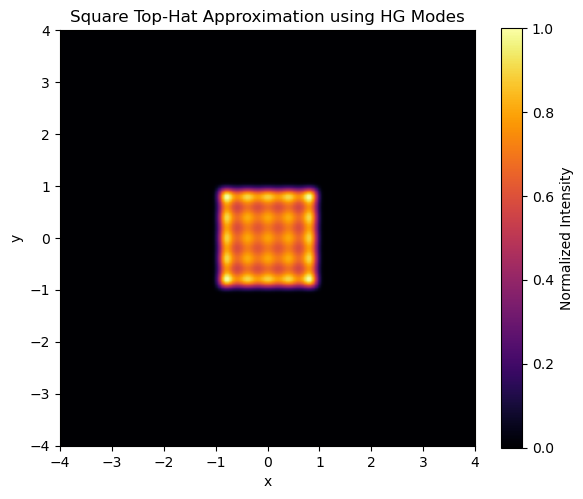

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite
from scipy.special import factorial

def HG_mode(n, x, w):
    Hn = hermite(n)
    norm = (2**n * factorial(n) * np.sqrt(np.pi) * w)**-0.5
    return norm * Hn(np.sqrt(2) * x / w) * np.exp(-x**2 / w**2)

# Parameters
N = 130  # Number of modes per axis
w = 1.5  # Beam waist
L = 4    # Spatial domain size
res = 300
x = np.linspace(-L, L, res)
y = np.linspace(-L, L, res)
X, Y = np.meshgrid(x, y)

# Construct target top-hat profile
a = 1.0
E_target = np.where((np.abs(X) < a) & (np.abs(Y) < a), 1.0, 0.0)

# Build HG basis and calculate coefficients
HG_basis_x = [HG_mode(n, x, w) for n in range(N)]
HG_basis_y = [HG_mode(n, y, w) for n in range(N)]

# Projection coefficients
c = np.zeros((N, N))
for m in range(N):
    for n in range(N):
        bx = HG_basis_x[m]
        by = HG_basis_y[n]
        Bx, By = np.meshgrid(bx, by)
        HGmn = Bx * By
        c[m, n] = np.sum(HGmn * E_target) * (x[1] - x[0]) * (y[1] - y[0])

# Reconstruct field
E_recon = np.zeros_like(E_target, dtype=np.complex128)
for m in range(N):
    for n in range(N):
        bx = HG_basis_x[m]
        by = HG_basis_y[n]
        Bx, By = np.meshgrid(bx, by)
        E_recon += c[m, n] * Bx * By

I_recon = np.abs(E_recon)**2
I_recon /= I_recon.max()

# Plot
plt.figure(figsize=(6, 5))
plt.imshow(I_recon, extent=(-L, L, -L, L), cmap='inferno')
plt.colorbar(label="Normalized Intensity")
plt.title("Square Top-Hat Approximation using HG Modes")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()
